# Examen entrenamiento de Redes Neuronales Artificiales

*  En este examen hay una parte de laboratorio y un problema.
*  Dentro del laboratorio vamos a tener distintas preguntas.
*  Se deberá entregar el fichero en formato ipynb y pdf.
*  En nombre del fichero debe de tener el siguiente formato: NOMBRE_APE1_APE2
*  Se puede utilizar el buscador Google, prácticas anteriores y apuntes de la asignatura.
*  Se valorará la originalidad de los experimentos, haciendose mucho hincapié en la calidad de la conclusión de los mismos.
*  Se tendrá en cuenta positivamente aquellos modelos con mejor desempeño.
*  Duración máxima 2:30

## **Laboratorio**

Hemos escogido el dataset CIFAR 10 para la realización de este laboratorio. CIFAR 10 pese a ser un dataset con fines académicos a la hora de procesar cada Epoch puede llegar fácilmente a durar más de 30 segundos, debido a eso en este examen siempre vamos utilizar **5 Epochs** para nuestros experimentos.

In [26]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test)=cifar10.load_data()

print('Shape of x_train is {}'.format(x_train.shape))
print('Shape of x_test is {}'.format(x_test.shape))
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

Shape of x_train is (50000, 32, 32, 3)
Shape of x_test is (10000, 32, 32, 3)
Shape of y_train is (50000, 1)
Shape of y_test is (10000, 1)


### **Preparación de datos**




#### 1) Realiza la normalización y hot enconding de este dataset. (0.5 puntos)

In [27]:
from tensorflow.keras.utils import to_categorical

# Normalizing
x_train=x_train/255
x_test=x_test/255

#One hot encoding
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

### **Experimento 1**

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten,Dropout,Input, AveragePooling2D, Activation,Conv2D, MaxPooling2D, BatchNormalization,Concatenate
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


#### 2) Elige el tipo de red neuronal óptimo visto en esta asignatura para este tipo de problemas, crea una arquitectura capaz de superar al **40 %** en el val_acurracy, utilizando el optimizador SGD y recuerda que sólo puedes utilizar 5 epochs para el entrenamiento. (1.5 puntos)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. Definición de la arquitectura (CNN)
model = Sequential([
    # Primera capa de extracción de características
    # Se añade el input_shape correspondiente a imágenes de CIFAR-10 (32x32 píxeles, 3 canales RGB)
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(), # Vital para acelerar la convergencia con SGD en pocas epochs
    MaxPooling2D((2, 2)),

    # Segunda capa para características más complejas
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Tercera capa para afinar aún más la extracción
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Aplanado para conectar con el clasificador final
    Flatten(),

    # Capa densa (clasificador) con Dropout para regularizar y evitar Overfitting
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Capa de salida: 10 neuronas (una por clase) con activación softmax
    Dense(10, activation='softmax')
])

# 2. Compilación del modelo
# Usamos 'categorical_crossentropy' porque las etiquetas pasaron por to_categorical() en la Pregunta 1
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 3. Configuración del Early Stopping
# Con solo 5 epochs es poco probable que salte, pero es una buena práctica incluirlo.
early_stop = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)

# 4. Entrenamiento del modelo
# Usamos x_train (normalizado) e y_train_cat (one-hot encoding)
history = model.fit(x_train, y_train_cat,
                    epochs=5, # Restricción estricta del examen
                    batch_size=64,
                    validation_data=(x_test, y_test_cat),
                    callbacks=[early_stop])

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4012 - loss: 1.7023 - val_accuracy: 0.4837 - val_loss: 1.4463
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.5258 - loss: 1.3362 - val_accuracy: 0.3918 - val_loss: 1.7654
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5803 - loss: 1.1902 - val_accuracy: 0.5877 - val_loss: 1.1548
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6151 - loss: 1.0948 - val_accuracy: 0.2493 - val_loss: 3.0561
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6418 - loss: 1.0232 - val_accuracy: 0.6115 - val_loss: 1.0870


In [30]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,100 (629.30 KB)

 Trainable params: 160,650 (627.54 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

### **Experimento 2**

In [31]:
# 1. Re-definición de la misma arquitectura exacta del Experimento 1
model_adam = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

# 2. Compilación del modelo (¡Aquí cambiamos a ADAM!)
model_adam.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# 3. Entrenamiento del modelo (mismas 5 epochs)
history_adam = model_adam.fit(x_train, y_train_cat,
                              epochs=5,
                              batch_size=64,
                              validation_data=(x_test, y_test_cat))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4859 - loss: 1.4464 - val_accuracy: 0.5399 - val_loss: 1.3305
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6213 - loss: 1.0673 - val_accuracy: 0.6227 - val_loss: 1.0723
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6830 - loss: 0.9064 - val_accuracy: 0.6461 - val_loss: 1.0136
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7202 - loss: 0.7984 - val_accuracy: 0.6701 - val_loss: 0.9611
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7472 - loss: 0.7181 - val_accuracy: 0.6340 - val_loss: 1.1686


In [32]:
model_adam.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 482,400 (1.84 MB)

 Trainable params: 160,650 (627.54 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 321,302 (1.23 MB)

####3) Utilizando el modelo que has utilizado en el modelo anterior cambia el optimizador a ADAM. Realice el entrenamiento, ¿ Han cambiado los parámetros del este modelo con respecto al anterior? justifique la respuesta. (1 punto)

Sí, aunque la arquitectura y los parámetros entrenables (160.650) permanecen idénticos, el número total de parámetros del modelo aumenta significativamente al cambiar a ADAM. Esto se debe a que, a diferencia de SGD, el optimizador ADAM necesita almacenar parámetros internos adicionales (denominados "momentos") para cada peso de la red con el fin de adaptar la tasa de aprendizaje de forma individual. Como se observa en los logs, ADAM añade dos estados por cada parámetro entrenable ($160.650 \times 2 + 2 = 321.302$), lo que explica por qué el total de parámetros del modelo se triplica en memoria (pasando de 161.100 a 482.400) para lograr una convergencia más rápida en pocas epochs.

####4) Realizar para ambos modelos una estructura de tabla de experimentación y de comparativa por epochs de val_acurracy en la visualización.  (0.5 puntos)

####5) Realizar una conclusión del motivo que un modelo ha funcionado mejor un modelo que el otro. (1 punto)

### **Experimento 3**

6) Al mejor modelo que hayas obtenido aplicar BatchNormalization (1 punto)

7) Mediante tabla y gráfica comparalo con el modelo anterior, realiza una conclusión de experimento (1 pto)

### **Experimento 4**

8) Image augmentation: Es una técnica utilizada para conseguir más datos a partir de los existentes, se pide utilizar esta técnica en el mejor modelo que hayamos tenido hasta el momento (1 punto)

#### 9) A partir del sumary del mejor modelo que hayamos obtenido, indica como se obtiene los parámetros de un tipo de cada capa, desarrolla tu respuesta mediante calculos matemáticos.(1 punto).

## **Problema**

Nuestras redes neuronales artificiales son grafos de computación, Tensorflow por dentro está formado por estos, en la siguiente imagen tienes un grafo de computación.

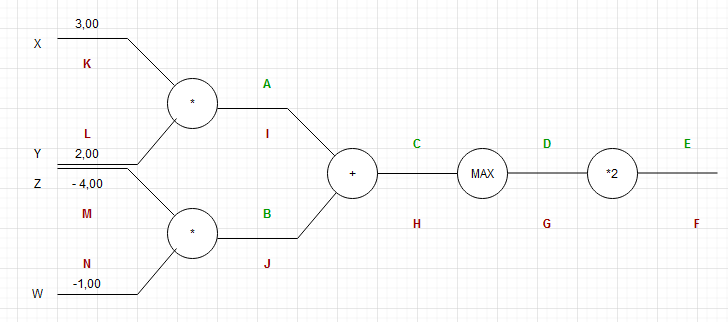

#### 10 ) A partir del grafo de computación aplica el algoritmo de backpropagation. (1.5 punto)

*  A:
*  B:
*  C:
*  D:
*  E:
*  F:
*  G:
*  H:
*  I:
*  J:
*  K:
*  L:
*  M:
*  N: